In [43]:
%load_ext autoreload
%autoreload 2
# %env CUDA_VISIBLE_DEVICES=0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Prelims

In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


In [45]:
split_id = 11042026
pd.set_option('display.max_rows', None)


In [46]:
from omegaconf import OmegaConf
log_dir = 'log_dir'
hostname_ = 'CIN'
dataset_name = 'areds_new'
project_dir = '/gpfs01/berens/user/inwabufo/leverage/leverage-data'
CLEANED_FILE= 'areds_new_results_cleaned_03_06_26_split_id_11042026'
config_file = '/gpfs01/berens/user/inwabufo/.secrets.yaml'
cfg = OmegaConf.load(config_file)
CHKPT_DIR = chkpt_dir = os.path.join(project_dir, 'chkpt_dir', 'npj_areds_curves')
RESULTS_DIR = os.path.join(project_dir, 'results')
project_dir = cfg['DATASETS'][hostname_][dataset_name]
stylef = cfg['stylef'][hostname_]
img_dir = f"{project_dir}"
img_dir

'/gpfs01/berens/user/inwabufo/data/AREDS/AREDS_macula'

In [47]:
stylef

'/gpfs01/berens/user/inwabufo/time_distance/time_distance/utils/berenslab.mplstyle'

In [48]:

df2 = pd.read_csv(os.path.join(log_dir, f"{CLEANED_FILE}.csv"))
df2['summary'].value_counts()

summary
simclr_inet_nako    140
dino_nako           140
simclr_nako         140
resnet_imagenet     140
retfound            140
dino_meta           140
nako_mae            140
scratch             140
Name: count, dtype: int64

In [49]:
def make_families(x):
    family= None
    if (x =='simclr_nako') or (x == 'simclr_inet_nako') or (x=='nako_mae'):
        family = 'SSL'
    elif (x=='dino_meta') or (x=='dino_nako') or (x=='retfound'):
        family = 'FM'
    elif (x=='scratch') or (x=='resnet_imagenet'):
        family = 'Sup.'
    else:
        raise ValueError('Unknown')
    return family

In [50]:
df2['model_family'] = df2['summary'].apply(lambda x: make_families(x) )
df2['model_family'].value_counts(dropna = False)

model_family
SSL     420
FM      420
Sup.    280
Name: count, dtype: int64

In [51]:
dino_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "dino_nako") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "dino_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "dino_nako") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "dino_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_nako_mlp_fef.shape, dino_nako_mlp_fet.shape, dino_nako_lin_fef.shape, dino_nako_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [52]:
dino_nako_mlp_fef['train_size'].value_counts()

train_size
100.0      5
500.0      5
20000.0    5
10000.0    5
1000.0     5
30000.0    5
32500.0    5
Name: count, dtype: int64

In [53]:
dino_meta_lin_fef = pd.DataFrame(df2[(df2['summary']  == "dino_meta")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_meta_lin_fet = pd.DataFrame(df2[(df2['summary']  == "dino_meta")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_meta_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "dino_meta")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_meta_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "dino_meta")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_meta_mlp_fef.shape, dino_meta_mlp_fet.shape, dino_meta_lin_fef.shape, dino_meta_lin_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [54]:
dino_meta_mlp_fef['train_size'].value_counts(dropna=False), dino_meta_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 500.0      5
 10000.0    5
 32500.0    5
 100.0      5
 20000.0    5
 1000.0     5
 30000.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 32500.0    5
 30000.0    5
 Name: count, dtype: int64)

In [55]:
simclr_inet_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_inet_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_inet_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_inet_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_inet_nako_lin_fef.shape, simclr_inet_nako_lin_fet.shape, simclr_inet_nako_mlp_fef.shape, simclr_inet_nako_mlp_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [56]:
simclr_inet_nako_mlp_fet['train_size'].value_counts(dropna=False), simclr_inet_nako_mlp_fef['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 20000.0    5
 500.0      5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 30000.0    5
 10000.0    5
 1000.0     5
 32500.0    5
 Name: count, dtype: int64)

In [57]:
simclr_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_nako_mlp_fef.shape, simclr_nako_mlp_fet.shape, simclr_nako_lin_fef.shape, simclr_nako_lin_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [58]:
simclr_nako_mlp_fef['train_size'].value_counts(dropna=False), simclr_nako_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64)

In [59]:
imagenet_resnet_lin_fef = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
imagenet_resnet_lin_fet = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
imagenet_resnet_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
imagenet_resnet_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
imagenet_resnet_mlp_fef.shape, imagenet_resnet_mlp_fet.shape, imagenet_resnet_lin_fef.shape, imagenet_resnet_lin_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [60]:
imagenet_resnet_mlp_fef['train_size'].value_counts(dropna=False), imagenet_resnet_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 20000.0    5
 30000.0    5
 1000.0     5
 100.0      5
 500.0      5
 10000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 32500.0    5
 30000.0    5
 20000.0    5
 10000.0    5
 1000.0     5
 500.0      5
 Name: count, dtype: int64)

In [61]:
resnet_scratch_lin_fef = pd.DataFrame(df2[(df2['summary']  == "scratch") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
resnet_scratch_lin_fet = pd.DataFrame(df2[(df2['summary']  == "scratch")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
resnet_scratch_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "scratch") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
resnet_scratch_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "scratch")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
resnet_scratch_mlp_fef.shape, resnet_scratch_mlp_fet.shape, resnet_scratch_lin_fef.shape, resnet_scratch_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [62]:
resnet_scratch_mlp_fef['train_size'].value_counts(dropna=False), resnet_scratch_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 32500.0    5
 20000.0    5
 10000.0    5
 500.0      5
 1000.0     5
 30000.0    5
 Name: count, dtype: int64)

In [63]:
retfound_lin_fef = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
retfound_lin_fet = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
retfound_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
retfound_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
retfound_mlp_fef.shape, retfound_mlp_fet.shape, retfound_lin_fef.shape, retfound_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [64]:
retfound_mlp_fef['train_size'].value_counts(dropna=False), retfound_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 1000.0     5
 500.0      5
 30000.0    5
 10000.0    5
 100.0      5
 20000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64)

In [65]:
nako_mae_lin_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_lin_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_mlp_fef.shape, nako_mae_mlp_fet.shape, nako_mae_lin_fef.shape, nako_mae_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [66]:
nako_mae_mlp_fef['train_size'].value_counts(dropna=False), nako_mae_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 1000.0     5
 10000.0    5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64)

In [67]:
all_plots = {
   
    "retfound_lin_fef":retfound_lin_fef,
    "retfound_lin_fet":retfound_lin_fet,

    "resnet_scratch_lin_fef": resnet_scratch_lin_fef,
    "resnet_scratch_lin_fet": resnet_scratch_lin_fet,
 
    "retfound_mlp_fef":retfound_mlp_fef,
    "retfound_mlp_fet":retfound_mlp_fet,

    "resnet_scratch_mlp_fef": resnet_scratch_mlp_fef,
    "resnet_scratch_mlp_fet": resnet_scratch_mlp_fet,

    "resnet_INet_lin_fef": imagenet_resnet_lin_fef,
    "resnet_INet_lin_fet": imagenet_resnet_lin_fet,

    "resnet_INet_mlp_fef": imagenet_resnet_mlp_fef,
    "resnet_INet_mlp_fet": imagenet_resnet_mlp_fet,

    "mae_nako_lin_fef": nako_mae_lin_fef,
    "mae_nako_lin_fet": nako_mae_lin_fet,

    "mae_nako_mlp_fef": nako_mae_mlp_fef,
    "mae_nako_mlp_fet": nako_mae_mlp_fet,

    "simclr_nako_lin_fef": simclr_nako_lin_fef,
    "simclr_nako_lin_fet": simclr_nako_lin_fet,

    "simclr_nako_mlp_fef": simclr_nako_mlp_fef,
    "simclr_nako_mlp_fet": simclr_nako_mlp_fet,

    "simclr_INet_nako_lin_fef": simclr_inet_nako_lin_fef,
    "simclr_INet_nako_lin_fet": simclr_inet_nako_lin_fet,

    "simclr_INet_nako_mlp_fef": simclr_inet_nako_mlp_fef,
    "simclr_INet_nako_mlp_fet": simclr_inet_nako_mlp_fet,

    "dino_nako_lin_fef": dino_nako_lin_fef,
    "dino_nako_lin_fet": dino_nako_lin_fet,

    "dino_nako_mlp_fef": dino_nako_mlp_fef,
    "dino_nako_mlp_fet": dino_nako_mlp_fet,

    "dino_meta_lin_fef": dino_meta_lin_fef,
    "dino_meta_lin_fet": dino_meta_lin_fet,

    "dino_meta_mlp_fef": dino_meta_mlp_fef,
    "dino_meta_mlp_fet": dino_meta_mlp_fet,
    }


In [68]:
"dino_meta_lin_fef".rsplit('_', 2)

['dino_meta', 'lin', 'fef']

In [69]:

stylefile =stylef
save_path = './figures'
os.makedirs(save_path, exist_ok=True)


In [70]:
fet_plots = all_plots.copy()
fet_keys_to_delete = [key for key in fet_plots if 'fef' in key]
for key in fet_keys_to_delete:
    del fet_plots[key]


In [71]:
fef_plots = all_plots.copy()
fef_keys_to_delete = [key for key in fef_plots if 'fet' in key]
for key in fef_keys_to_delete:
    del fef_plots[key]

In [72]:
save_path

'./figures'

seems like there is something wrong with computing on cin

In [73]:
save_path = './figures/saimi'

In [74]:
from plotting_utils import plot_finetuning_strategies

In [75]:
y_ticks_list1 = [0.05, 0.08, 0.11]   # example — adjust spacing as you like
y_ticks_list2 = [0.50,  0.75,  1.0]   

In [76]:
# eraser_linewidth = max(3.0, spine_linewidth * 2)


In [77]:
axis_br_size=0.01
axis_br_gap=0.018
axis_br_y_pos=-0.03      # more negative → more vertical clearance from x-axis
axis_br_x_pos=-0.01 

In [78]:
save_path = './figures'

In [79]:
import matplotlib, shutil
shutil.rmtree(matplotlib.get_cachedir())

FileNotFoundError: [Errno 2] No such file or directory: '/gpfs01/berens/user/inwabufo/.cache/matplotlib'

findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, san

metrics test/ibs
min y-axis 0.0539, max y-axis 0.1022
metrics test/concordance_index
min y-axis 0.5561, max y-axis 0.9201
6.0
no supxlabel yet


findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, san

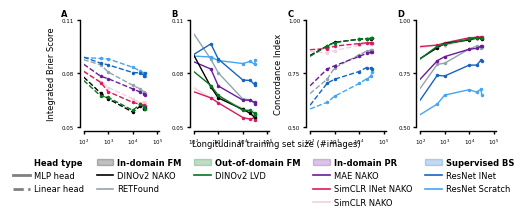

findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: Arial, san

(<Figure size 626.772x150 with 4 Axes>,
 array([<Axes: ylabel='Integrated Brier Score'>, <Axes: >,
        <Axes: ylabel='Concordance Index'>, <Axes: >], dtype=object))

In [80]:
plot_finetuning_strategies(fet_plots, show_count=False,
                        more_suptitle = 'Freezing Encoder', 
                        save_path = os.path.join(save_path, '0_areds_fet'), 
                        to_plot = 'mlp',
                        stylef = '/gpfs01/berens/user/inwabufo/leverage/mpl.mplstyle', 
                        num_y_ticks = 2,  
                        axis_br_size=axis_br_size,
                        axis_br_gap=axis_br_gap,
                        axis_br_y_pos=axis_br_y_pos,      # more negative → more vertical clearance from x-axis
                        axis_br_x_pos=axis_br_x_pos,  
                        y_ticks_list1=y_ticks_list1,
                        y_ticks_list2=y_ticks_list2,
                        define_ticks=True,
                        text_y=1.10,
                        text_x=-0.3,
                        tick_length = 2,
                        tick_width = 1


)

metrics test/ibs
min y-axis 0.0506, max y-axis 0.0916
metrics test/concordance_index
min y-axis 0.5224, max y-axis 0.9331
6.0
no supxlabel yet


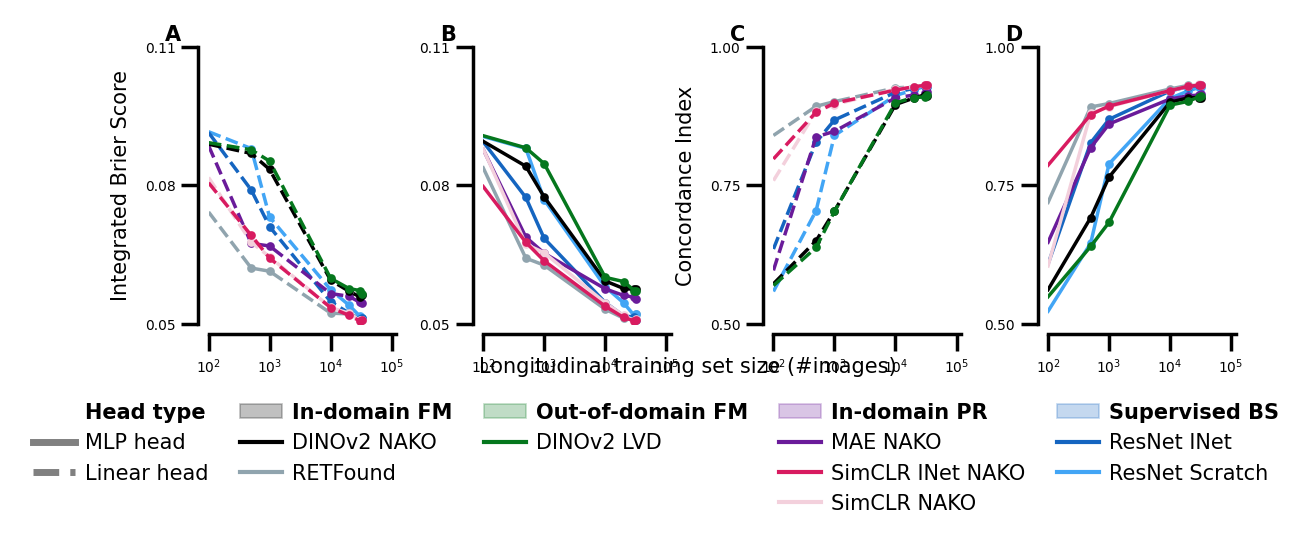

(<Figure size 1566.93x375 with 4 Axes>,
 array([<Axes: ylabel='Integrated Brier Score'>, <Axes: >,
        <Axes: ylabel='Concordance Index'>, <Axes: >], dtype=object))

In [ ]:
plot_finetuning_strategies(fef_plots, show_count=False,
                    more_suptitle = 'Not Freezing Encoder', 
                    save_path = os.path.join(save_path, '0_areds_fef'), 
                    to_plot = 'mlp',
                    stylef = stylefile, num_y_ticks = 2,  
                    axis_br_size = axis_br_size,
                    axis_br_gap = axis_br_gap, 
                    axis_br_y_pos =axis_br_y_pos, 
                    axis_br_x_pos=axis_br_x_pos,
                    y_ticks_list1 = y_ticks_list1, # [0.05, 0.075, 0.095], 
                    y_ticks_list2=y_ticks_list2, #[0.5, 0.75, 0.95],
                    text_y=1.08,
                                            text_x=-0.23,
)

In [ ]:
from plotting_utils import plot_finetuning_strategies_2x2

min y-axis 0.0539, max y-axis 0.1022
min y-axis 0.5561, max y-axis 0.9201


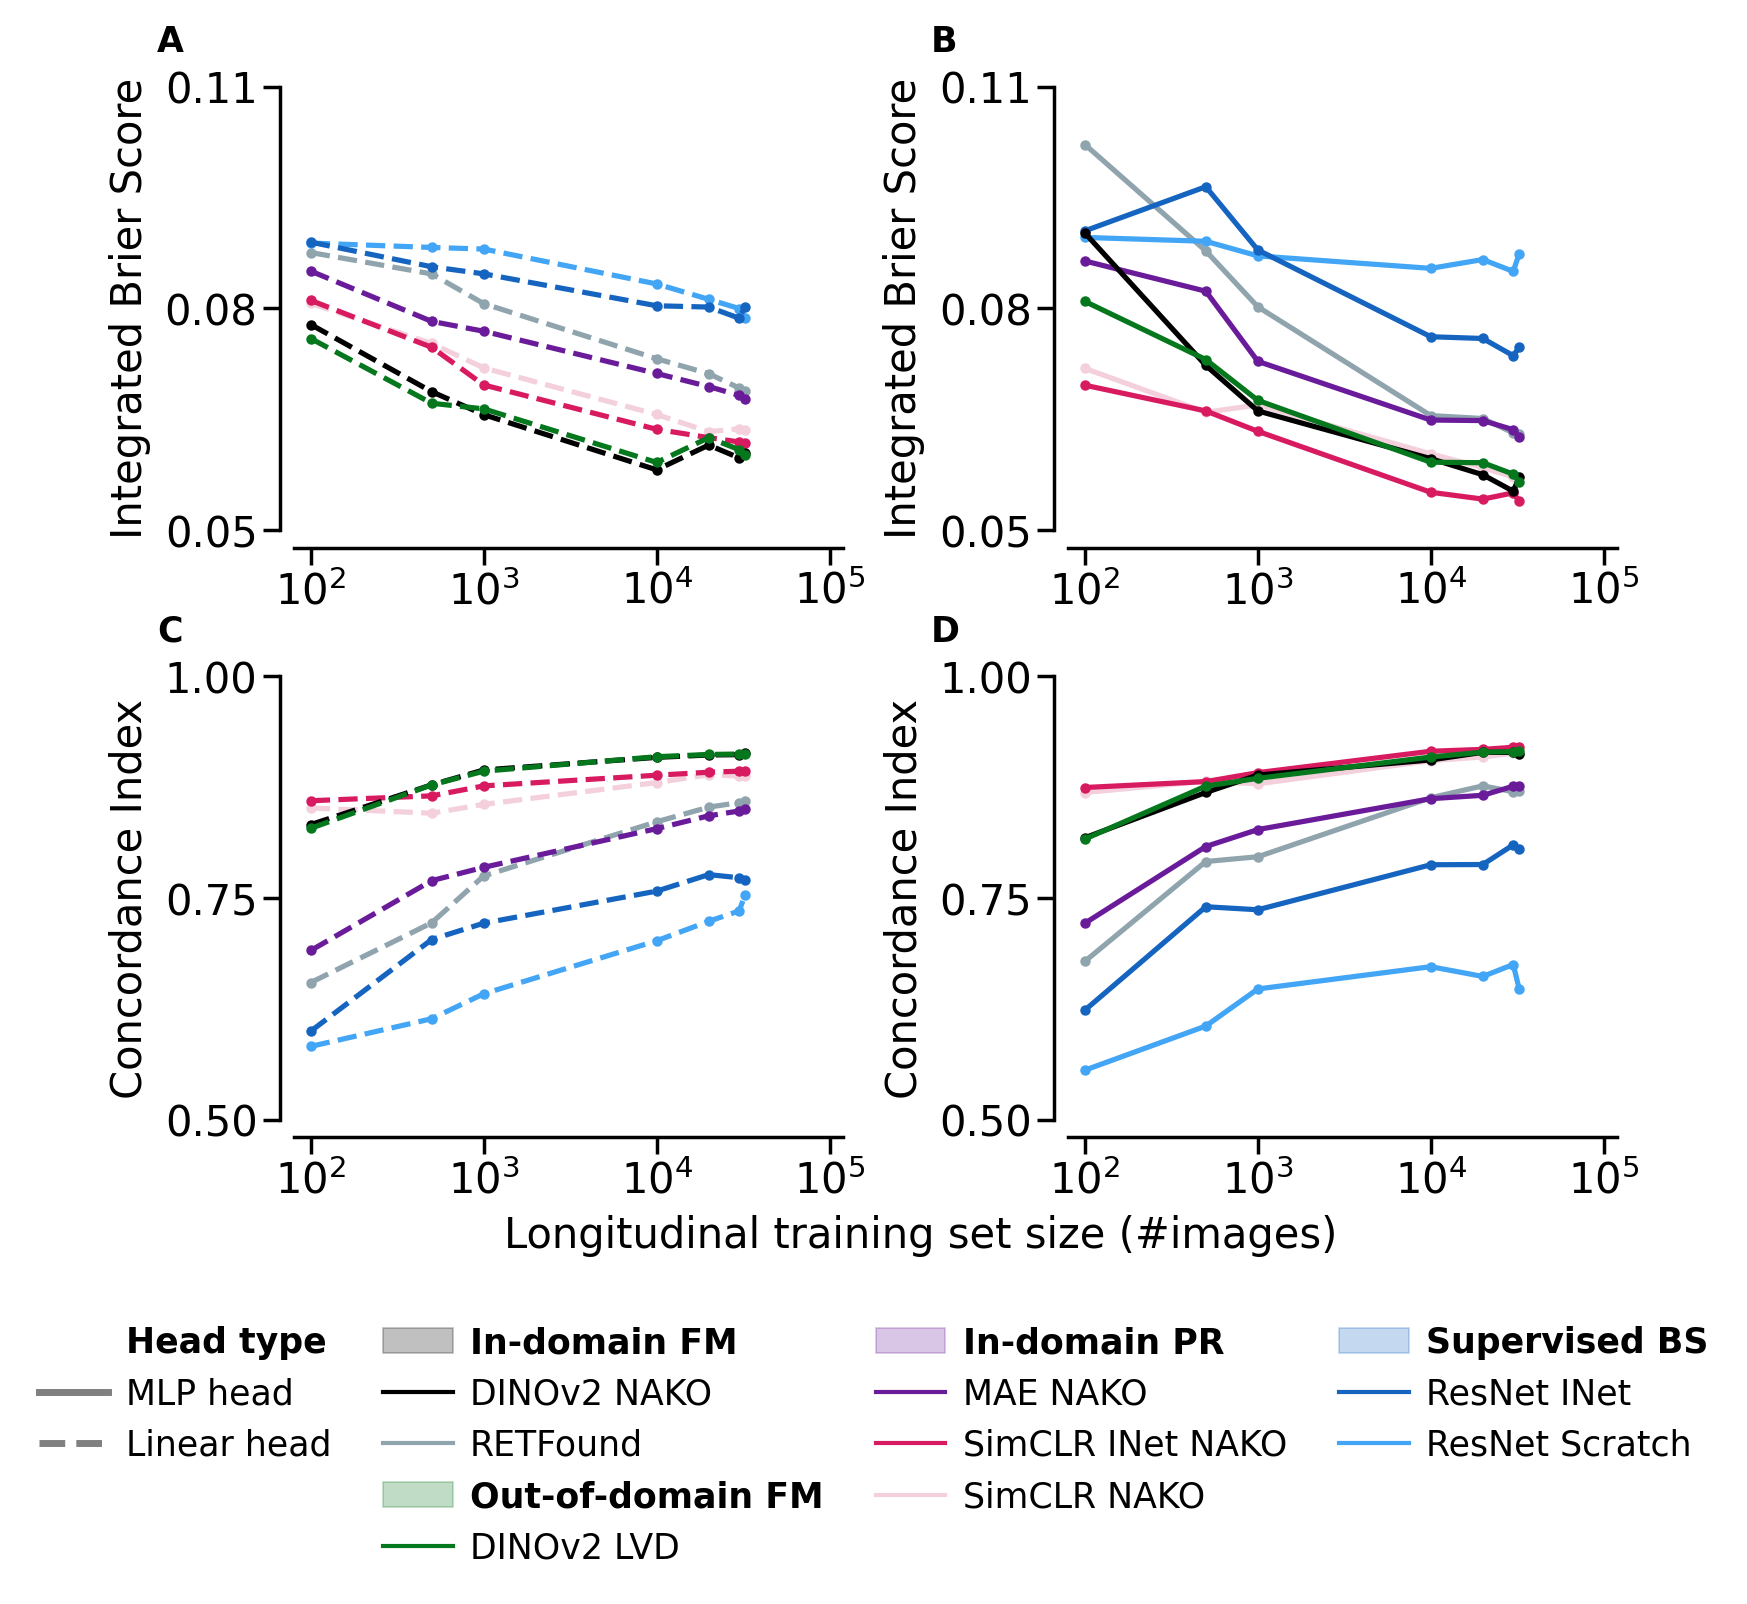

(<Figure size 1566.93x1258.94 with 4 Axes>,
 array([[<Axes: ylabel='Integrated Brier Score'>,
         <Axes: ylabel='Integrated Brier Score'>],
        [<Axes: ylabel='Concordance Index'>,
         <Axes: ylabel='Concordance Index'>]], dtype=object))

In [ ]:
plot_finetuning_strategies_2x2(fet_plots, show_count=False,
                        # more_suptitle = 'Freezing Encoder', 
                        save_path = os.path.join(save_path, '01_areds_fet.pdf'), 
                        to_plot = 'mlp',
                        stylef = stylefile, 
                        num_y_ticks = 2,  
                        axis_br_size=axis_br_size,
                        axis_br_gap=axis_br_gap,
                        axis_br_y_pos=axis_br_y_pos,      # more negative → more vertical clearance from x-axis
                        axis_br_x_pos=axis_br_x_pos,  
                        y_ticks_list1=y_ticks_list1,
                        y_ticks_list2=y_ticks_list2,
                        define_ticks=True,
                        text_y=1.140,
                        text_x=-0.25
                        )

min y-axis 0.0506, max y-axis 0.0916
min y-axis 0.5224, max y-axis 0.9331


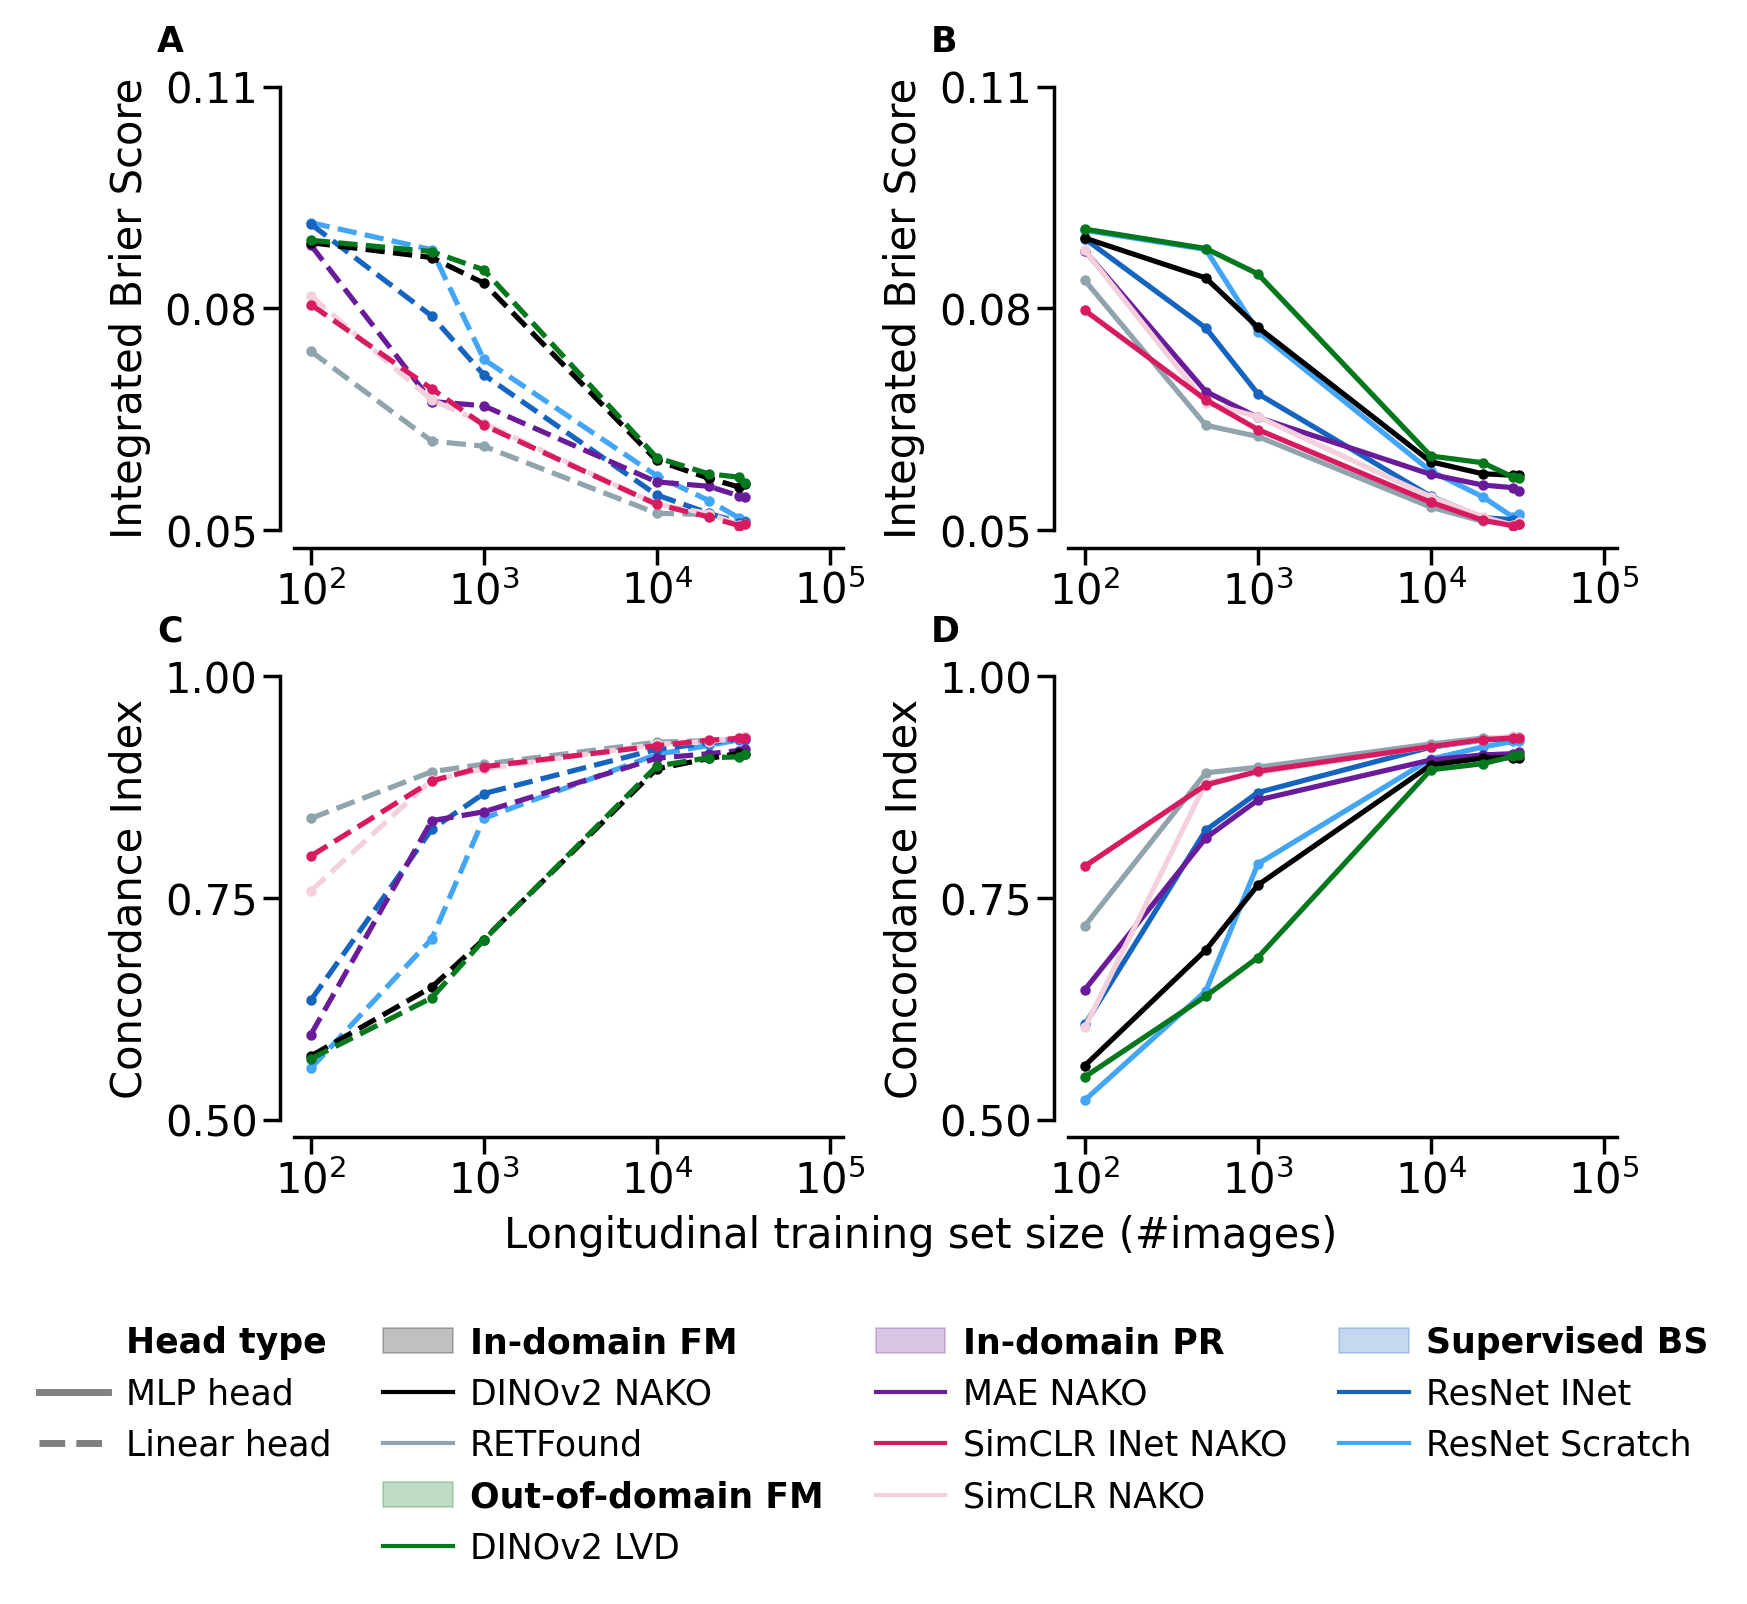

(<Figure size 1566.93x1258.94 with 4 Axes>,
 array([[<Axes: ylabel='Integrated Brier Score'>,
         <Axes: ylabel='Integrated Brier Score'>],
        [<Axes: ylabel='Concordance Index'>,
         <Axes: ylabel='Concordance Index'>]], dtype=object))

In [ ]:
plot_finetuning_strategies_2x2(fef_plots, show_count=False,
                        # more_suptitle = 'Freezing Encoder', 
                        save_path = os.path.join(save_path, '01_areds_fef.pdf'), 
                        to_plot = 'mlp',
                        stylef = stylefile, 
                        num_y_ticks = 2,  
                        axis_br_size=axis_br_size,
                        axis_br_gap=axis_br_gap,
                        axis_br_y_pos=axis_br_y_pos,      # more negative → more vertical clearance from x-axis
                        axis_br_x_pos=axis_br_x_pos,  
                        y_ticks_list1=y_ticks_list1,
                        y_ticks_list2=y_ticks_list2,
                        define_ticks=True,
                        text_y=1.140,
                        text_x=-0.25)